# Interaction-conditioned generation with ShEPhERD-2

This tutorial demonstrates how to use ShEPhERD-2 for various applications. We cover these use-cases:
- Interaction-conditioned generation
- Generation with subselection of profiles
- Generation with pharmacophore prioritization
- Generation with scaffold conditioning
- Extra inpainting settings

In [1]:
%load_ext autoreload
%autoreload 2

from rdkit import Chem
import numpy as np
import torch

from shepherd import load_model
from shepherd.extract import mol_charges_from_samples
from shepherd.interaction_profile import InteractionProfile, extract_interaction_profile, InpaintAdvancedOptions
from shepherd.generated_sample import GeneratedSample

from shepherd_score.conformer_generation import embed_conformer_from_smiles
from shepherd.visualize import draw_sample, draw_mol, draw_profile, view_sample_trajectory, draw_2d_highlight

# faster inference
torch.set_float32_matmul_precision("high")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Load MOSES model
Downloads from Huggingface automatically.

In [2]:
model = load_model(
    model_type='mosesaq',
    inference_only=True,
    device='cuda'
)

Loading mosesaq (inference) model from: /orcd/home/002/kento/.cache/huggingface/hub/models--kabeywar--shepherd2-dev/snapshots/afadb288329c0a434f035218e489c3c20c1cc8e4/shepherd2/shepherd2-mosesaq-inference.ckpt
Using device: cuda
Successfully loaded mosesaq model


### Load reference molecule
To condition generation, we require an rdkit `Mol` object that has explicit hydrogens and a 3D conformation.

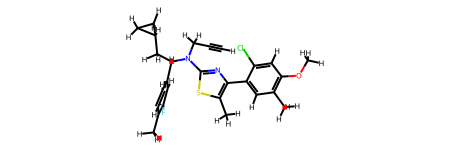

In [ ]:
# This is an example. Usually we prefer to load a molecule with a pre-specified conformation.
# crinecerfont
ref_mol = embed_conformer_from_smiles('CC1=C(C=C(C=C1)[C@H](CC2CC2)N(CC#C)C3=NC(=C(S3)C)C4=C(C=C(C(=C4)C)OC)Cl)F', random_seed=0)
display(ref_mol)

We need an interaction profile to condition on. Note that `ref_profile.mol` is translated so that its COM is at the origin due to `center=True`. Therefore, it is different from `ref_mol`. We can recover the original position from `ref_profile.com_before_centering`.

In [4]:
ref_profile = extract_interaction_profile(
    ref_mol,
    # We automatically relax the molecule with xTB.
    # You will want to set this to `False` if you are using
    # e.g., a crystal structure where the exact pose is important.
    xtb_optimize=True,
    center=True
)

Visualize this reference molecule and its interaction profile

In [ ]:
view = draw_profile(ref_profile)
view.show()

### Interaction conditioned generation
Generate samples conditioned on the full interaction profile. Adjust `batch_size`, `N_x1`, and `N_x4` as you'd like. Increasing `N_x` slightly above the number of atoms in the reference gives ShEPhERD-2 extra flexibility to remove superfluous atoms as dummy atoms.

`N_x1` also accepts a list of ints if you want to vary the number of atoms within a batch. Similarly, `N_x4` accepts a list of ints as well, with the additional requirement that `N_x4 >= ref_profile.n_pharms` (to correctly inpaint all of them).
In both cases, `len(N_x1) == batch_size` and `len(N_x4) == batch_size`.

The first step will take a minute or two due to graph compilation. Afterwards, there will be no delay.

In [6]:
conditional_samples: list[GeneratedSample] = model.generate(
    batch_size = 10, # tune based on GPU, low for demonstration purposes
    N_x1 = ref_profile.n_atoms + 4, # number of atoms in the sample, increasing this allows for dummy atoms to absorb extra atoms
    N_x4 = ref_profile.n_pharms, # number of pharmacophores in the sample
    condition = ref_profile,
    condition_modalities = 'all', # you can subselect e.g., {'shape', 'pharm'}
)

EDM Steps (conditional): 100%|██████████| 360/360 [00:51<00:00,  6.97it/s]


In [7]:
len(conditional_samples)

10

We can extract the raw generated outputs as shown below.

In [8]:
# index into the list to get a sample
# x1 (atoms)
print(f'atom types: {conditional_samples[0].atoms}')
print(f'atom pos (shape): {conditional_samples[0].positions.shape}')
# x2 (surface)
print(f'surface (shape): {conditional_samples[0].surface.shape}')
# x3 (electrostatics)
print(f'electrostatics (shape): {conditional_samples[0].electrostatics.shape}')
# x4 (pharmacophores)
print(f'pharm types: {conditional_samples[0].pharm_types}')
print(f'pharm pos (shape): {conditional_samples[0].pharm_positions.shape}')
print(f'pharm direction (shape): {conditional_samples[0].pharm_directions.shape}')

atom types: [ 1  6  6  1  6  1  1  6  1  6  1  1  7  8  1  6  7  1  6  1  6  1  6  1
  1  0  6  6  1  6  1  1  1  1  6  1  7  1  6  6  6  1  6  1  6  1  1  6
  1  6 17  6  1  1  1  6  1  1  1  6  6  7  0  6  6]
atom pos (shape): (65, 3)
surface (shape): (75, 3)
electrostatics (shape): (75,)
pharm types: [2 2 2 0 0 4 4 3 3 3 3 3 3 3 3 3 3 3]
pharm pos (shape): (18, 3)
pharm direction (shape): (18, 3)


You can visualize these raw samples in 3D

In [ ]:
view = draw_mol(ref_profile.mol, opacity=0.5)
view = draw_sample(conditional_samples[3], view=view)
view.show()

The above visualization is just a rendering of the raw generated sample. We can convert these generated samples to RDKit `Mol` objects.
We can do this through various ways:

- We can obtain an `InteractionProfile` object from the generated sample. We can get the mol from `InteractionProfile.mol`
    - GeneratedSample.to_interaction_profile()
    - InteractionProfile.from_generated_sample()

- We can also directly obtain a `(Mol, np.ndarray)` tuple where the ndarray are the xTB-computed partial charges
    - mol_charges_from_sample()
    - GeneratedSample.to_mol_charges()

Typically, we relax the XYZ geometry *prior* to extraction. You can either supply a charge, or let the code determine it automatically.

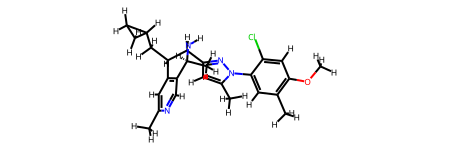

In [10]:
# may take a couple seconds for xTB relaxation
cond_sample_IP = conditional_samples[0].to_interaction_profile(
    xtb_optimize = True, # default
    center=False
)
display(cond_sample_IP.mol)

You can also visualize samples in 3D, overlayed with the reference.

In [ ]:
view = draw_profile(ref_profile, opacity=0.5)
view = draw_mol(cond_sample_IP.mol, view=view)
view.show()

Likely, you just want the "valid" samples. we can obtain those as follows

In [12]:
valid_mol_charges = mol_charges_from_samples(
    conditional_samples,
    num_workers = 10, # parallelize xtb optimizations over samples
    xtb_timeout = 60,
    verbose = True,
)
valid_mol_charges = [(m, c) for m, c in valid_mol_charges if m is not None]
print(f'We have {len(valid_mol_charges)} valid samples ({len(valid_mol_charges) / len(conditional_samples) * 100:.2f}%)')

100%|██████████| 10/10 [00:07<00:00,  1.36it/s]

We have 9 valid samples (90.00%)


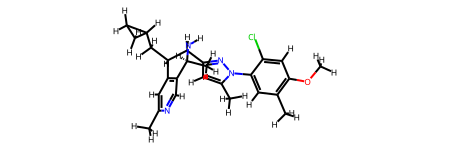

In [13]:
valid_mol_charges[0][0] # first index is the sample, second is (mol, charges)

## Generation with a subselection of profiles
It could be the case that you only want to condition on a subset of profiles such as just shape. You can do this easily:

In [14]:
conditional_samples_subset: list[GeneratedSample] = model.generate(
    batch_size = 10,
    N_x1 = ref_profile.n_atoms + 4,
    N_x4 = ref_profile.n_pharms,
    condition = ref_profile,
    condition_modalities = 'shape', # choose multiple modalities, too: {'shape', 'pharm'}
)

EDM Steps (conditional): 100%|██████████| 360/360 [00:23<00:00, 15.59it/s]


In [15]:
# visualize raw sample
view = draw_mol(ref_profile.mol, opacity=0.5)
view = draw_sample(conditional_samples_subset[0], view=view, model_type='x3')
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Conditional generation with scaffold conditioning

We can fix any subset of atoms during generation. 

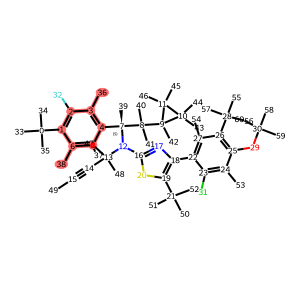

In [16]:
atom_inds = [1, 2, 3, 4, 5, 6, 36, 38]
draw_2d_highlight(ref_mol, [atom_inds], label='atomLabel', height=300, width=300)

We can add these atom inds as conditional information to the InteractionProfile in two different ways.
- Use `InteractionProfile.with_condition_atoms(atom_inds)` if you already have an instantiated `InteractionProfile`
- From the initial construction of the `InteractionProfile`

In [17]:
# This returns a new InteractionProfile object with the labeling of the condition gatoms.
ref_profile_with_scaff = ref_profile.with_condition_atoms(atom_inds)

In [19]:
# commented out since we already have an instantiated InteractionProfile
# ref_profile_with_scaff = extract_interaction_profile(ref_mol, ..., condition_atom_inds = atom_inds)

In [18]:
conditional_samples_scaff: list[GeneratedSample] = model.generate(
    batch_size = 10,
    N_x1 = ref_profile_with_scaff.n_atoms + 5, # recommended to add extra atoms for scaffold conditioning
    N_x4 = ref_profile_with_scaff.n_pharms,
    condition = ref_profile_with_scaff,
    condition_modalities = 'all',

    # add this argument
    scaffold_conditioning = True, # by flipping this to True, we fix the atoms in InteractionProfile.condition_atoms

    store_trajectories=True, # optional, to visualize the generation trajectory later
)

EDM Steps (conditional): 100%|██████████| 360/360 [00:23<00:00, 15.21it/s]


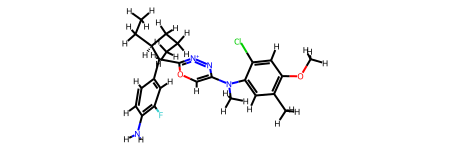

In [19]:
cond_sample_scaff_IP = conditional_samples_scaff[0].to_interaction_profile(
    xtb_optimize = False, # default
    center=False
)
display(cond_sample_scaff_IP.mol)

We can visualize the trajectories to see that the scaffold is fixed, as expected.

In [ ]:
view_sample_trajectory(conditional_samples_scaff[0], only_atoms=True, ref_mol=ref_profile.mol);

## Conditional generation with pharmacophore prioritization
To prioritize certain pharmacophores over others, we can fix "high priority" pharmacophores during generation while inpainting the "low priority" ones. Alternatively, you could ONLY fix the high priority and ignore low priority.

We will first visualize the molecule with it's atom inds which are used to select the pharmacophores. For example, let's assume we want to only prioritize two hydrogen bond acceptors.

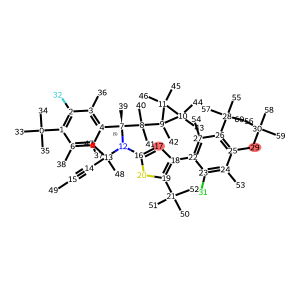

In [20]:
# atom_inds = [12, 15]
atom_inds = [29, 17]
draw_2d_highlight(ref_mol, [atom_inds], label='atomLabel', height=300, width=300)

We can visualize the atom inds that are selected using `InteractionProfile.subselection_pharm()`. Note that the default uses `min_ring_priority_atoms=1` which means that if a single selected atom is part of a ring, it will additionally include the pharmacophore related to that ring. We raise this to `min_ring_priority_atoms=3` so that we require at least 3 atoms on the ring to include it as a pharmacophore.

`InteractionProfile.subselection_pharm()` returns a copy of the original `InteractionProfile` with **only** the selected pharmacophores. Do **not** use this object for pharmacophore prioritization, only if you wanted to strictly condition on a subset of pharmacophores (and no inpainting of the rest).

In [ ]:
draw_profile(
    ref_profile.subselection_pharm(
        atom_inds,
        min_ring_priority_atoms=3 # Sets the minimum number of ring atoms selected to include hydrophobe/aromatic groups
    ),
    no_surface_points=True
)

Pharmacophore prioritization with `Shepherd.generate` requires an array of 1's (high priority) and 0's (low priority). If we are satisfied with the selection of the pharmacophores, we can construct this array with `InteractionProfile.pharm_prioritization_labels()`

In [21]:
pharm_prioritization_labels = ref_profile.pharm_prioritization_labels(
    atom_inds,
    min_ring_priority_atoms=3 # this must match the min_ring_priority_atoms in the subselection cell to ensure that you are prioritizing the same atoms
)
pharm_prioritization_labels

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
conditional_samples_pharm_prior: list[GeneratedSample] = model.generate(
    batch_size = 10,
    N_x1 = ref_profile.n_atoms+5,
    N_x4 = ref_profile.n_pharms,
    condition = ref_profile,
    condition_modalities = 'all',

    # add these two arguments
    pharmacophore_conditioning = True, # necessary for pharmacophore prioritization
    pharmacophore_prioritization = pharm_prioritization_labels, # removing this is equivalent to setting all to 1 (high priority)

    store_trajectories=True, # optional, to visualize the generation trajectory later
)

EDM Steps (conditional): 100%|██████████| 360/360 [00:23<00:00, 15.27it/s]


You can visualize the trajectory and observe that the prioritized pharmacophores remain fixed throughout, while the others are inpainted.

In [41]:
view_sample_trajectory(conditional_samples_pharm_prior[0], only_atoms=False);

Naturally, you can do all sorts of combinations of scaffold conditioning, pharmacophore prioritization, etc.

### Advanced inpainting controls

If you want finer grained control over inpainting, this can be done with the `InpaintAdvancedOptions` class.
Options include:
- Specifying the exact modalities that you do or don't want to inpaint (bool).
- Specifying if you want inpainting to terminate after fraction of the trajectory (float). These modalities are freely diffused afterwards.
- Adding extra noise to the inpainted positions throughout denoising (float).

In [ ]:
samples = model.generate(
    batch_size=48,
    N_x1=ref_profile.n_atoms,
    N_x4=ref_profile.n_pharms,
    condition=ref_profile,
    inpaint=InpaintAdvancedOptions(
        inpaint_x1_pos=True, # inpaint atom positions (assuming ref_profile has ConditionAtoms)
        inpaint_x3_x=False, # don't inpaint ESP values
        stop_inpainting_at_time_x4=0.9, # stop inpainting after 90% of the trajectory for pharmacophores
        stop_inpainting_at_time_x3=0.9, # stop inpainting after 90% of the trajectory for ESP/surface
    ),
)